In [258]:
import torch

from pprint import pprint
from decoder_patching import *
from utils import REPO_ROOT, preprocess_mask_predict_data

In [259]:
iter_nums = 10

prep_result = preprocess_mask_predict_data(
    input_dir=REPO_ROOT / "input",
    output_dir=REPO_ROOT / "output",
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    run_name="en_de_demo",
    workers=10,
)

In [260]:
state = torch.load("./checkpoints/maskPredict_en_de/checkpoint_best.pt", map_location="cpu", weights_only=False)
model_args = state["args"]

for k in [
    "arch",
    "encoder_layers",
    "encoder_embed_dim",
    "encoder_ffn_embed_dim",
    "encoder_attention_heads",
    "decoder_layers",
    "decoder_embed_dim",
    "decoder_ffn_embed_dim",
    "decoder_attention_heads",
]:
    if hasattr(model_args, k):
        print(k, "=", getattr(model_args, k))


arch = bert_transformer_seq2seq
encoder_layers = 6
encoder_embed_dim = 512
encoder_ffn_embed_dim = 2048
encoder_attention_heads = 8
decoder_layers = 6
decoder_embed_dim = 512
decoder_ffn_embed_dim = 2048
decoder_attention_heads = 8


In [261]:
context = load_mask_predict_context(
    data_bin_dir=prep_result["data_bin_dir"],
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    decoding_iterations=iter_nums,
    length_beam=1,
    max_sentences=20,
    use_cpu=True,
)

In [262]:
encoder_example = get_encoder_output(
    "China is a large country in Asia , and the capital of the country is Beijing .",
    context,
)

print("sentence:", encoder_example["sentence"])
print("src_tokens shape:", tuple(encoder_example["src_tokens"].shape))
print("src_lengths:", encoder_example["src_lengths"].tolist())
print("predicted target length:", int(encoder_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))

sentence: China is a large country in Asia , and the capital of the country is Beijing .
src_tokens shape: (1, 18)
src_lengths: [18]
predicted target length: 16


## Test on patching

In [ ]:
# source_sentence = "The bank was steep beside the stream ."
# target_sentence = "The bank was open beside the market ."
source_sentence = "The bank was open beside the market ."
target_sentence = "The bank is open beside the market ."

source_example = get_encoder_output(source_sentence, context)
target_example = get_encoder_output(target_sentence, context)

In [264]:
print("patch source sentence:", source_example["sentence"])
print("patch target sentence:", target_example["sentence"])
src_dict = context["task"].source_dictionary
source_token_ids = source_example["src_tokens"][0].tolist()
target_token_ids = target_example["src_tokens"][0].tolist()
source_token_text = [src_dict[token_id] for token_id in source_token_ids]
target_token_text = [src_dict[token_id] for token_id in target_token_ids]
print("patch source token ids:", [source_token_ids])
print("patch source token texts:", source_token_text)
print("patch source token pairs:", list(zip(source_token_ids, source_token_text)))
print("patch target token ids:", [target_token_ids])
print("patch target token texts:", target_token_text)
print("patch target token pairs:", list(zip(target_token_ids, target_token_text)))
print("patch source predicted target length:", int(source_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))
print("patch target predicted target length:", int(target_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))

patch source sentence: The bank was open beside the market .
patch target sentence: The bank is open beside the park .
patch source token ids: [[30, 2711, 66, 861, 20645, 7, 375, 6, 2]]
patch source token texts: ['The', 'bank', 'was', 'open', 'beside', 'the', 'market', '.', '</s>']
patch source token pairs: [(30, 'The'), (2711, 'bank'), (66, 'was'), (861, 'open'), (20645, 'beside'), (7, 'the'), (375, 'market'), (6, '.'), (2, '</s>')]
patch target token ids: [[30, 2711, 16, 861, 20645, 7, 2281, 6, 2]]
patch target token texts: ['The', 'bank', 'is', 'open', 'beside', 'the', 'park', '.', '</s>']
patch target token pairs: [(30, 'The'), (2711, 'bank'), (16, 'is'), (861, 'open'), (20645, 'beside'), (7, 'the'), (2281, 'park'), (6, '.'), (2, '</s>')]
patch source predicted target length: 9
patch target predicted target length: 9


In [265]:
layer_index = 5

source_predicted_length = int(source_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item())
target_predicted_length = int(target_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item())

print("decoder layer index:", layer_index)
print("patch mode:", "full_layer")
print("source predicted target length:", source_predicted_length)
print("target predicted target length:", target_predicted_length)
print("full layer patch requires matching lengths:", source_predicted_length == target_predicted_length)

decoder layer index: 5
patch mode: full_layer
source predicted target length: 9
target predicted target length: 9
full layer patch requires matching lengths: True


In [266]:
decoded_original_target = decode_from_encoder_output(
    target_example["encoder_out"],
    context=context,
    decoding_iterations=iter_nums,
)

decoder_patch_result = decoder_patching(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    layer_index=layer_index,
    decoding_iterations=iter_nums,
)

In [267]:
print("source sentence:", source_sentence)
print("target sentence:", target_sentence)
print("decoded from original target encoder:", decoded_original_target["decoded_text"])
print("decoded from decoder-patched target:", decoder_patch_result["decoded_text"])
print()
print("patched decoder iteration trace:")
for step in decoder_patch_result["iteration_trace"]:
    print(f"iter {step['iteration']:02d}: {step['text']}")
    print("  selected mask tokens:", step["selected_mask_tokens"])
    print("  selected mask probs:", step["selected_mask_probs"])
    print("  token mask probs:", step["token_mask_probs"])

source sentence: The bank was open beside the market .
target sentence: The bank is open beside the park .
decoded from original target encoder: Die Bank ist neben dem Park geöffnet .
decoded from decoder-patched target: Die Bank war neben dem Markt offen .

patched decoder iteration trace:
iter 00: Die Bank war neben dem Markt geöffnet .
  selected mask tokens: []
  selected mask probs: []
  token mask probs: [0.096946, 0.06864, 0.126653, 0.059814, 0.153072, 0.095572, 0.543789, 0.099744, 0.089825]
iter 01: Die Bank war neben dem Markt offen .
  selected mask tokens: ['geöffnet', 'dem', 'war', '.', 'Die', 'Markt', '</s>', 'Bank']
  selected mask probs: [0.543789, 0.153072, 0.126653, 0.099744, 0.096946, 0.095572, 0.089825, 0.06864]
  token mask probs: [0.095437, 0.054433, 0.098538, 0.059814, 0.099032, 0.055285, 0.537595, 0.099236, 0.090667]
iter 02: Die Bank war neben dem Markt geöffnet .
  selected mask tokens: ['offen', '.', 'dem', 'war', 'Die', '</s>', 'neben']
  selected mask probs:

In [268]:
print("decoder patch activation trace:")
for step in decoder_patch_result["patch_trace"]:
    print(f"iter {step['iteration']:02d}:")
    print("  activation shape:", step["activation_shape"])
    print("  source text:", step["source_text"])
    print("  patched text:", step["patched_text"])


decoder patch activation trace:
iter 00:
  activation shape: [9, 1, 512]
  source text: Die Bank war neben dem Markt geöffnet .
  patched text: Die Bank war neben dem Markt geöffnet .
iter 01:
  activation shape: [9, 1, 512]
  source text: Die Bank war neben dem Markt offen .
  patched text: Die Bank war neben dem Markt offen .
iter 02:
  activation shape: [9, 1, 512]
  source text: Die Bank war neben dem Markt geöffnet .
  patched text: Die Bank war neben dem Markt geöffnet .
iter 03:
  activation shape: [9, 1, 512]
  source text: Die Bank war neben dem Markt offen .
  patched text: Die Bank war neben dem Markt offen .
iter 04:
  activation shape: [9, 1, 512]
  source text: Die Bank war neben dem Markt offen .
  patched text: Die Bank war neben dem Markt offen .
iter 05:
  activation shape: [9, 1, 512]
  source text: Die Bank war neben dem Markt offen .
  patched text: Die Bank war neben dem Markt offen .
iter 06:
  activation shape: [9, 1, 512]
  source text: Die Bank war neben dem M

In [269]:
final_predicted_sentence = decoder_patch_result["decoded_text"]
print("final predicted sentence:", final_predicted_sentence)

final predicted sentence: Die Bank war neben dem Markt offen .


In [270]:
pprint(decoder_patch_result["patch_trace"][-1])

{'activation_shape': [9, 1, 512],
 'iteration': 9,
 'patch_mode': 'full_layer',
 'patched_text': 'Die Bank war neben dem Markt offen .',
 'source_activation_norm': 28.913698,
 'source_text': 'Die Bank war neben dem Markt offen .',
 'target_activation_norm_after_patch': 28.913698,
 'target_activation_norm_before_patch': 31.635979}


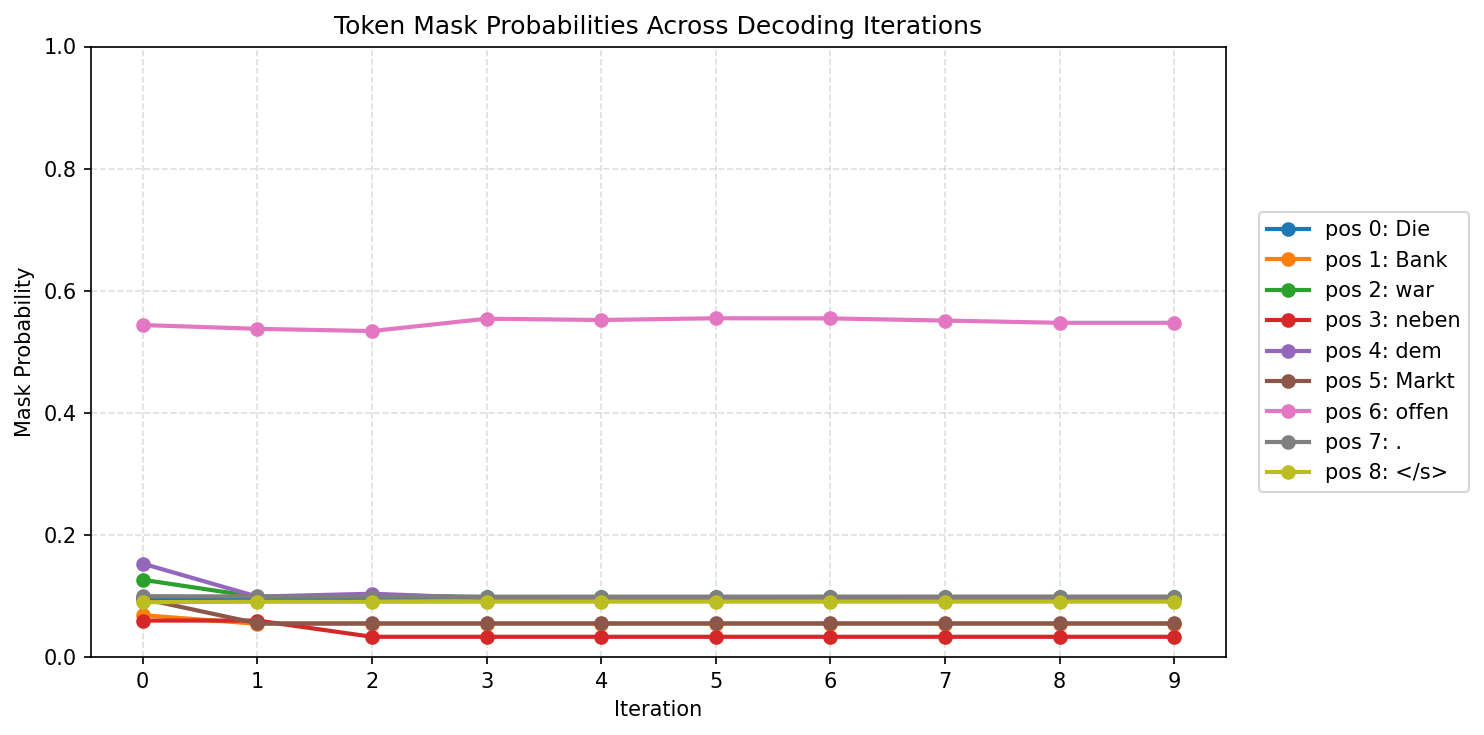

In [271]:
plot_token_mask_probs(decoder_patch_result)

In [272]:
print("final iteration mask probabilities:", decoder_patch_result["iteration_trace"][-1]["token_mask_probs"])


final iteration mask probabilities: [0.097603, 0.054433, 0.097859, 0.033242, 0.096397, 0.055285, 0.547484, 0.099104, 0.09082]


In [273]:
patched_token_idx = 2
tracked_token_id = decoded_original_target["token_ids"][patched_token_idx]
tracked_token_text = context["task"].target_dictionary[tracked_token_id]

print("tracked token position:", patched_token_idx)
print("tracked token in original target decode:", tracked_token_text)
print("original target decode:", decoded_original_target["decoded_text"])


tracked token position: 2
tracked token in original target decode: ist
original target decode: Die Bank ist neben dem Park geöffnet .


In [274]:
layer_sweep_result = decoder_layer_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=patched_token_idx,
    decoding_iterations=iter_nums,
)


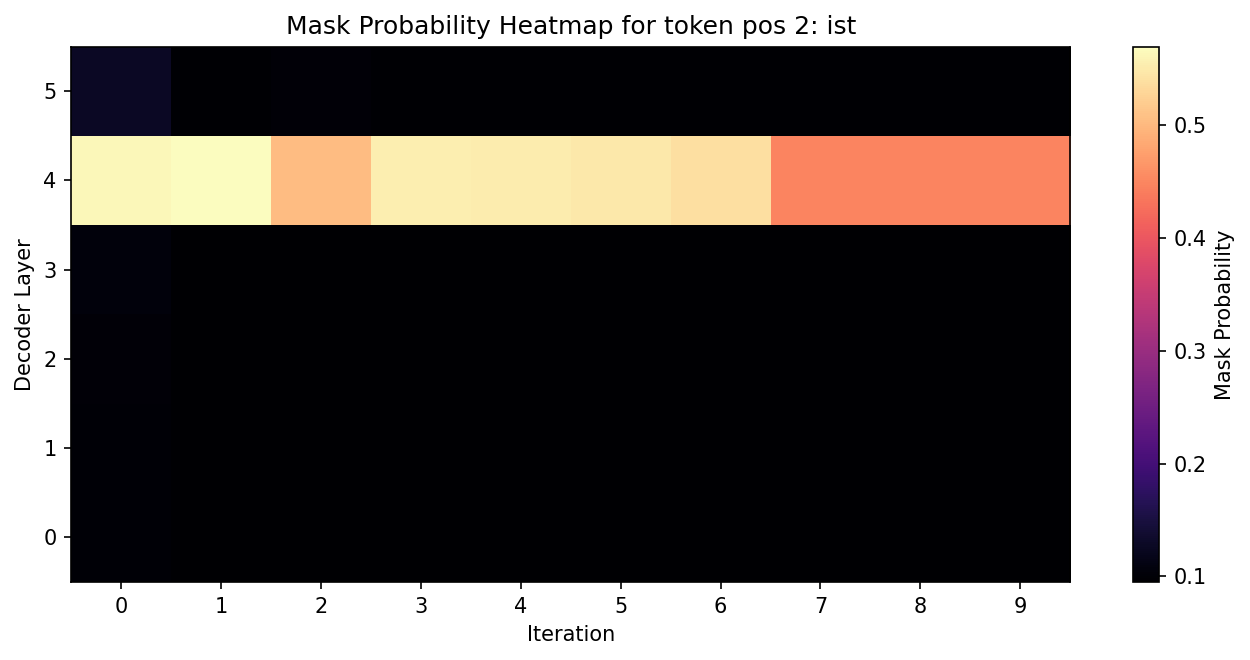

In [275]:
plot_layerwise_token_mask_heatmap(layer_sweep_result)


In [276]:
self_attn_layer_index = 5
self_attn_token_position = 2
self_attn_token_id = decoded_original_target["token_ids"][self_attn_token_position]
self_attn_token_text = context["task"].target_dictionary[self_attn_token_id]

print("self-attn layer index:", self_attn_layer_index)
print("self-attn token position:", self_attn_token_position)
print("tracked target token in original decode:", self_attn_token_text)


self-attn layer index: 5
self-attn token position: 2
tracked target token in original decode: ist


In [277]:
decoder_self_attn_patch_result = decoder_self_attn_token_patching(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    layer_index=self_attn_layer_index,
    token_position=self_attn_token_position,
    decoding_iterations=iter_nums,
)


In [278]:
print("decoded from original target encoder:", decoded_original_target["decoded_text"])
print("decoded from decoder self-attn patched target:", decoder_self_attn_patch_result["decoded_text"])
print()
print("decoder self-attn patch trace:")
for step in decoder_self_attn_patch_result["patch_trace"]:
    print(f"iter {step['iteration']:02d}:")
    print("  patch mode:", step["patch_mode"])
    print("  module:", step["module_name"])
    print("  token position:", step["token_position"])
    print("  source text:", step["source_text"])
    print("  patched text:", step["patched_text"])


decoded from original target encoder: Die Bank ist neben dem Park geöffnet .
decoded from decoder self-attn patched target: Die Bank ist neben dem Park geöffnet .

decoder self-attn patch trace:
iter 00:
  patch mode: self_attn_source_to_target
  module: decoder.layers.5.self_attn
  token position: 2
  source text: Die Bank war neben dem Markt geöffnet .
  patched text: Die Bank ist neben dem Park geöffnet .
iter 01:
  patch mode: self_attn_source_to_target
  module: decoder.layers.5.self_attn
  token position: 2
  source text: Die Bank war neben dem Markt offen .
  patched text: Die Bank ist neben dem Park geöffnet .
iter 02:
  patch mode: self_attn_source_to_target
  module: decoder.layers.5.self_attn
  token position: 2
  source text: Die Bank war neben dem Markt geöffnet .
  patched text: Die Bank ist neben dem Park geöffnet .
iter 03:
  patch mode: self_attn_source_to_target
  module: decoder.layers.5.self_attn
  token position: 2
  source text: Die Bank war neben dem Markt offen 

In [279]:
final_self_attn_predicted_sentence = decoder_self_attn_patch_result["decoded_text"]
print("final self-attn patched target sentence:", final_self_attn_predicted_sentence)


final self-attn patched target sentence: Die Bank ist neben dem Park geöffnet .


In [280]:
bank_token_id = decoded_original_target["token_ids"][patched_token_idx]
bank_token_text = context["task"].target_dictionary[bank_token_id]
self_attn_iters = list(range(iter_nums))

print("bank token position:", patched_token_idx)
print("bank token in original target decode:", bank_token_text)
print("self-attn sweep patch iterations:", self_attn_iters)


bank token position: 2
bank token in original target decode: ist
self-attn sweep patch iterations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [281]:
self_attn_bank_sweep_result = decoder_self_attn_layer_iteration_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=patched_token_idx,
    patch_token_position=patched_token_idx,
    decoding_iterations=iter_nums,
    patch_iterations=self_attn_iters,
)


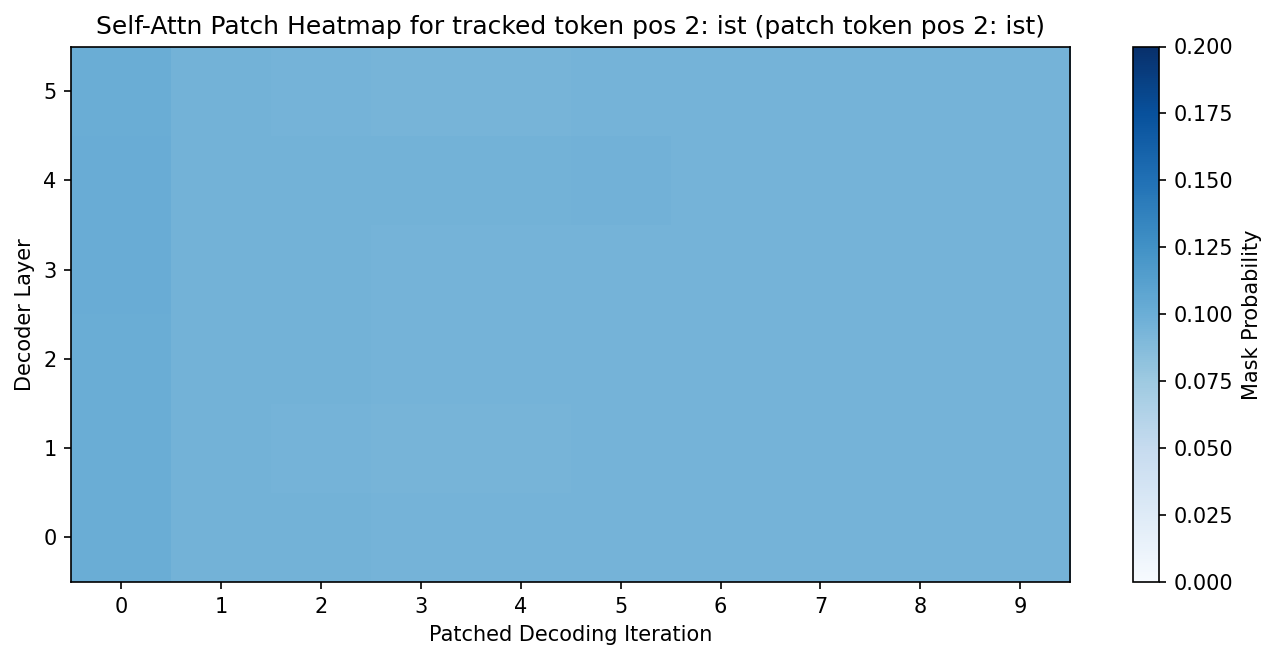

In [282]:
plot_self_attn_layer_iteration_heatmap(self_attn_bank_sweep_result,cmap="Blues")


In [283]:
cross_attn_layer_index = 5
cross_attn_token_position = patched_token_idx
cross_attn_token_id = decoded_original_target["token_ids"][cross_attn_token_position]
cross_attn_token_text = context["task"].target_dictionary[cross_attn_token_id]

print("cross-attn layer index:", cross_attn_layer_index)
print("cross-attn token position:", cross_attn_token_position)
print("tracked target token in original decode:", cross_attn_token_text)


cross-attn layer index: 5
cross-attn token position: 2
tracked target token in original decode: ist


In [284]:
decoder_cross_attn_patch_result = decoder_cross_attn_token_patching(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    layer_index=cross_attn_layer_index,
    token_position=cross_attn_token_position,
    decoding_iterations=iter_nums,
)


In [285]:
print("decoded from original target encoder:", decoded_original_target["decoded_text"])
print("decoded from decoder cross-attn patched target:", decoder_cross_attn_patch_result["decoded_text"])
print()
print("decoder cross-attn patch trace:")
for step in decoder_cross_attn_patch_result["patch_trace"]:
    print(f"iter {step['iteration']:02d}:")
    print("  patch mode:", step["patch_mode"])
    print("  module:", step["module_name"])
    print("  token position:", step["token_position"])
    print("  source text:", step["source_text"])
    print("  patched text:", step["patched_text"])
    print("  activation shape:", step["activation_shape"])
    print("  source activation norm:", step["source_activation_norm"])
    print("  target activation norm before patch:", step["target_activation_norm_before_patch"])
    print("  target activation norm after patch:", step["target_activation_norm_after_patch"])


decoded from original target encoder: Die Bank ist neben dem Park geöffnet .
decoded from decoder cross-attn patched target: Die Bank ist neben dem Park geöffnet .

decoder cross-attn patch trace:
iter 00:
  patch mode: cross_attn_source_to_target
  module: decoder.layers.5.encoder_attn
  token position: 2
  source text: Die Bank war neben dem Markt geöffnet .
  patched text: Die Bank ist neben dem Park geöffnet .
  activation shape: [512]
  source activation norm: 4.956717
  target activation norm before patch: 3.907728
  target activation norm after patch: 4.956717
iter 01:
  patch mode: cross_attn_source_to_target
  module: decoder.layers.5.encoder_attn
  token position: 2
  source text: Die Bank war neben dem Markt offen .
  patched text: Die Bank ist neben dem Park geöffnet .
  activation shape: [512]
  source activation norm: 4.88988
  target activation norm before patch: 3.757154
  target activation norm after patch: 4.88988
iter 02:
  patch mode: cross_attn_source_to_target
  m

In [286]:
final_cross_attn_predicted_sentence = decoder_cross_attn_patch_result["decoded_text"]
print("final cross-attn patched target sentence:", final_cross_attn_predicted_sentence)


final cross-attn patched target sentence: Die Bank ist neben dem Park geöffnet .


In [287]:
cross_attn_iters = list(range(iter_nums))

print("cross-attn bank token position:", patched_token_idx)
print("cross-attn bank token in original target decode:", bank_token_text)
print("cross-attn sweep patch iterations:", cross_attn_iters)


cross-attn bank token position: 2
cross-attn bank token in original target decode: ist
cross-attn sweep patch iterations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [288]:
cross_attn_bank_sweep_result = decoder_cross_attn_layer_iteration_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=patched_token_idx,
    patch_token_position=patched_token_idx,
    decoding_iterations=iter_nums,
    patch_iterations=cross_attn_iters,
)


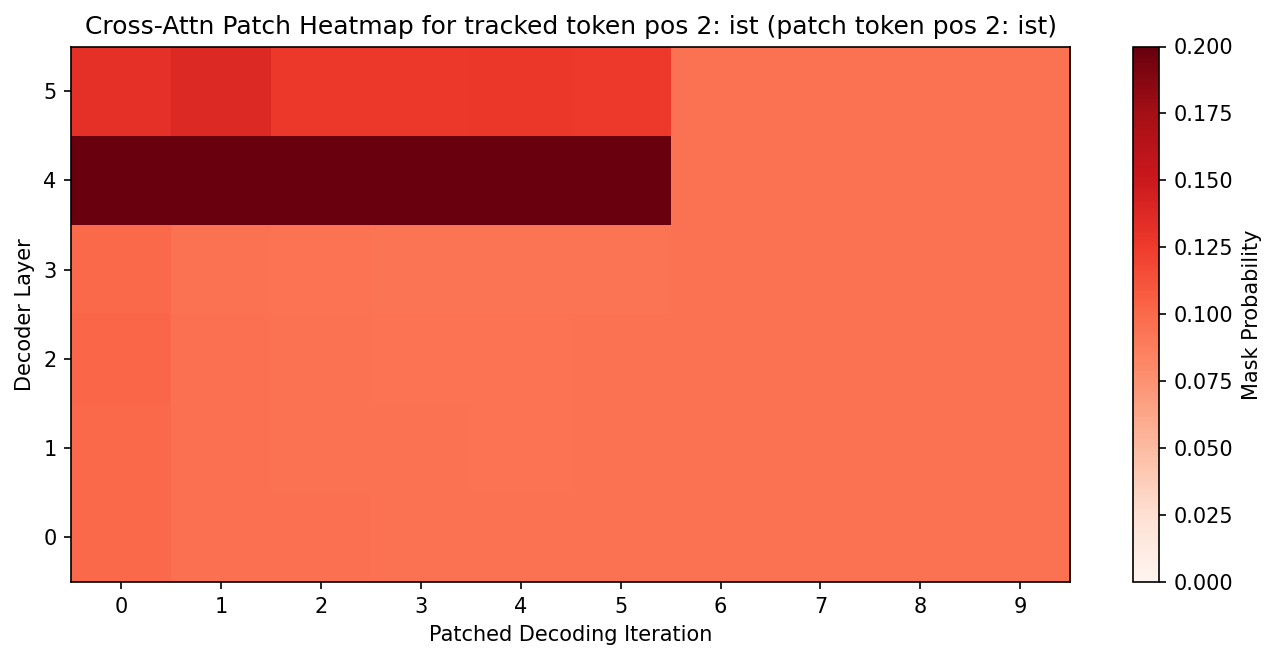

In [289]:
plot_cross_attn_layer_iteration_heatmap(cross_attn_bank_sweep_result, cmap="Reds")


## Full-layer patching

In [290]:
self_attn_full_iters = list(range(iter_nums))

print("self-attn full-layer bank token position:", patched_token_idx)
print("self-attn full-layer bank token in original target decode:", bank_token_text)
print("self-attn full-layer sweep patch iterations:", self_attn_full_iters)


self-attn full-layer bank token position: 2
self-attn full-layer bank token in original target decode: ist
self-attn full-layer sweep patch iterations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [291]:
self_attn_full_layer_bank_sweep_result = decoder_self_attn_full_layer_iteration_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=patched_token_idx,
    decoding_iterations=iter_nums,
    patch_iterations=self_attn_full_iters,
)


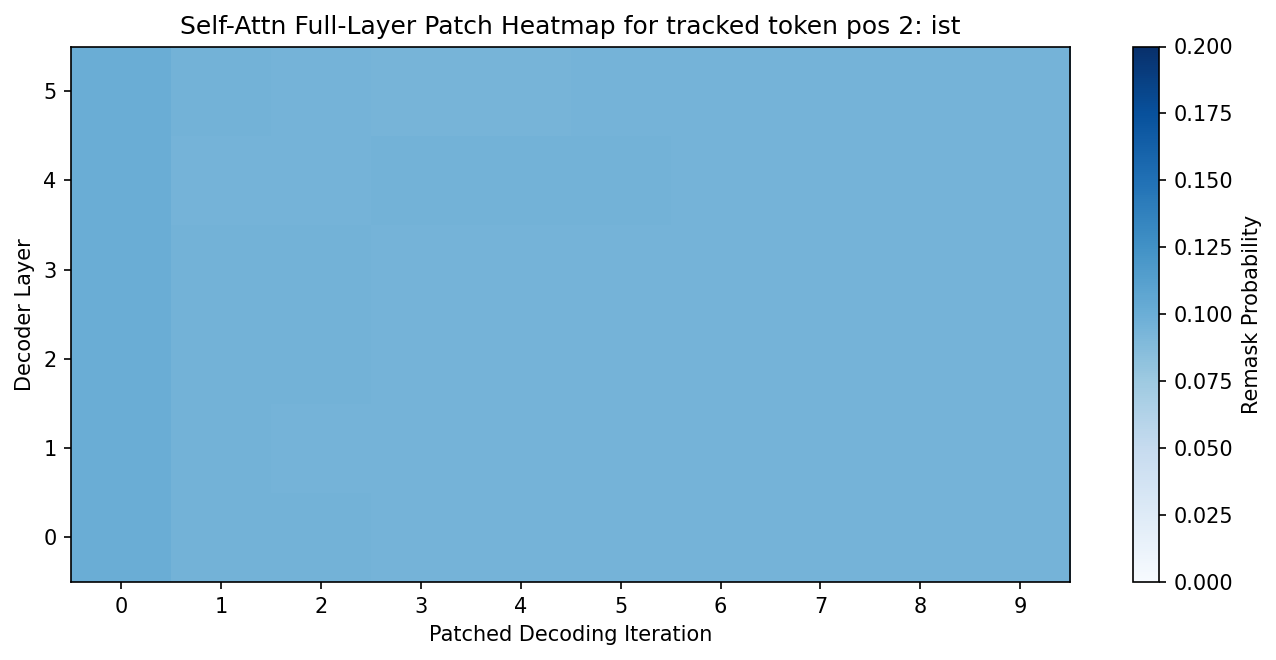

In [292]:
plot_self_attn_full_layer_iteration_heatmap(self_attn_full_layer_bank_sweep_result, cmap="Blues")


In [293]:
cross_attn_full_iters = list(range(iter_nums))

print("cross-attn full-layer bank token position:", patched_token_idx)
print("cross-attn full-layer bank token in original target decode:", bank_token_text)
print("cross-attn full-layer sweep patch iterations:", cross_attn_full_iters)


cross-attn full-layer bank token position: 2
cross-attn full-layer bank token in original target decode: ist
cross-attn full-layer sweep patch iterations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [294]:
cross_attn_full_layer_bank_sweep_result = decoder_cross_attn_full_layer_iteration_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=patched_token_idx,
    decoding_iterations=iter_nums,
    patch_iterations=cross_attn_full_iters,
)


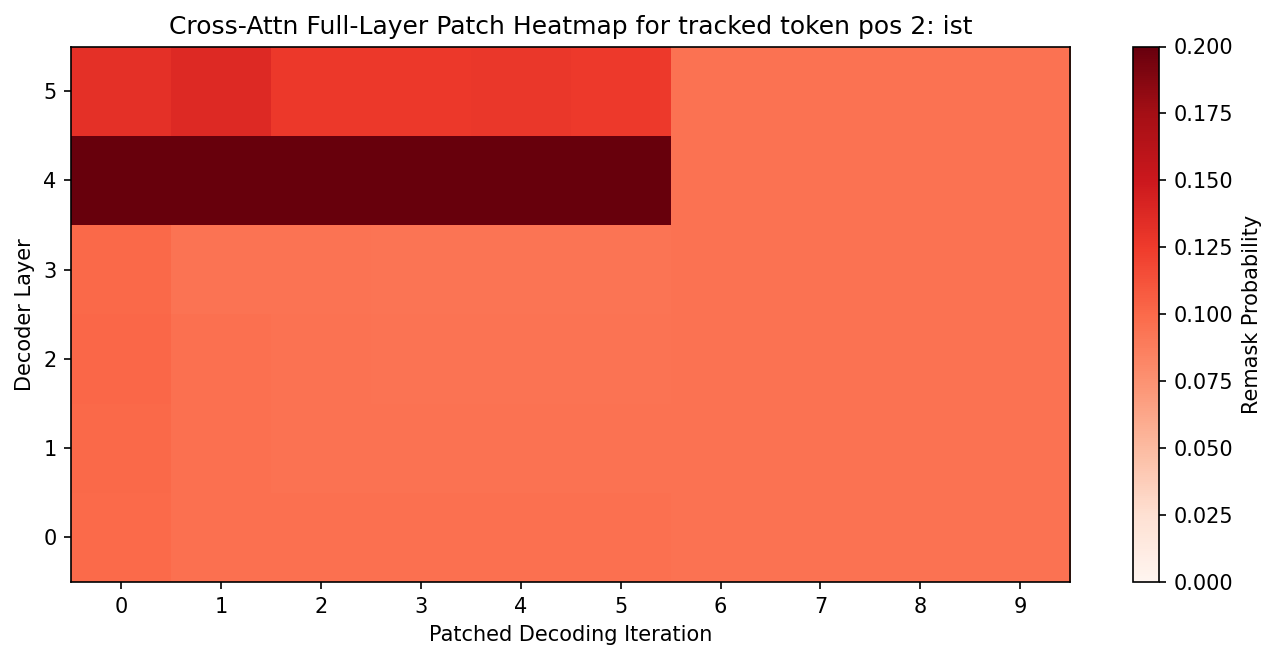

In [295]:
plot_cross_attn_full_layer_iteration_heatmap(cross_attn_full_layer_bank_sweep_result, cmap="Reds")


## Self-attn zero-out


In [296]:
self_attn_zero_out_layer_indices = list(range(len(context["model"].decoder.layers)))
self_attn_zero_out_average_layer_indices = self_attn_zero_out_layer_indices[:5]

print("self-attn zero-out layer indices:", self_attn_zero_out_layer_indices)
print("self-attn average layer indices (first 5 layers):", self_attn_zero_out_average_layer_indices)
print("target sentence for self-attn zero-out:", target_sentence)

self-attn head zero layer index: 5
target sentence for head zero ablation: The bank is open beside the park .


In [297]:
self_attn_zero_out_layer_sweep_result = decoder_self_attn_zero_out_layer_sweep(
    target_sentence=target_sentence,
    context=context,
    layer_indices=self_attn_zero_out_layer_indices,
    average_layer_indices=self_attn_zero_out_average_layer_indices,
    decoding_iterations=iter_nums,
)

In [298]:
print("self-attn zero-out results by layer:")
for layer_result in self_attn_zero_out_layer_sweep_result["layer_results"]:
    print(f"layer {layer_result['layer_index']}:")
    for head_result in layer_result["head_results"]:
        print(
            f"  head {head_result['head_index']}: overall avg mask prob = {head_result['overall_average_mask_prob']}"
        )
        print("    avg mask probs by iteration:", head_result["average_token_mask_probs_by_iteration"])
        print("    decoded text:", head_result["decoded_text"])

self-attn head zero ablation results:
head 0: overall avg mask prob = 0.088547
  avg mask probs by iteration: [0.093601, 0.0887, 0.088101, 0.088248, 0.088513, 0.088668, 0.0876, 0.087389, 0.087327, 0.087327]
  decoded text: Die Bank ist neben dem Park geöffnet .
head 1: overall avg mask prob = 0.089605
  avg mask probs by iteration: [0.099177, 0.091216, 0.090297, 0.090314, 0.087586, 0.087605, 0.08757, 0.087395, 0.087444, 0.087444]
  decoded text: Die Bank ist neben dem Park geöffnet .
head 2: overall avg mask prob = 0.086572
  avg mask probs by iteration: [0.096255, 0.087551, 0.086605, 0.086688, 0.087053, 0.086925, 0.083563, 0.083676, 0.0837, 0.0837]
  decoded text: Die Bank ist neben dem Park geöffnet .
head 3: overall avg mask prob = 0.101561
  avg mask probs by iteration: [0.112374, 0.102635, 0.101185, 0.101282, 0.103127, 0.103256, 0.103094, 0.098694, 0.095007, 0.094957]
  decoded text: Die Bank ist neben dem Park geöffnet .
head 4: overall avg mask prob = 0.079886
  avg mask probs b

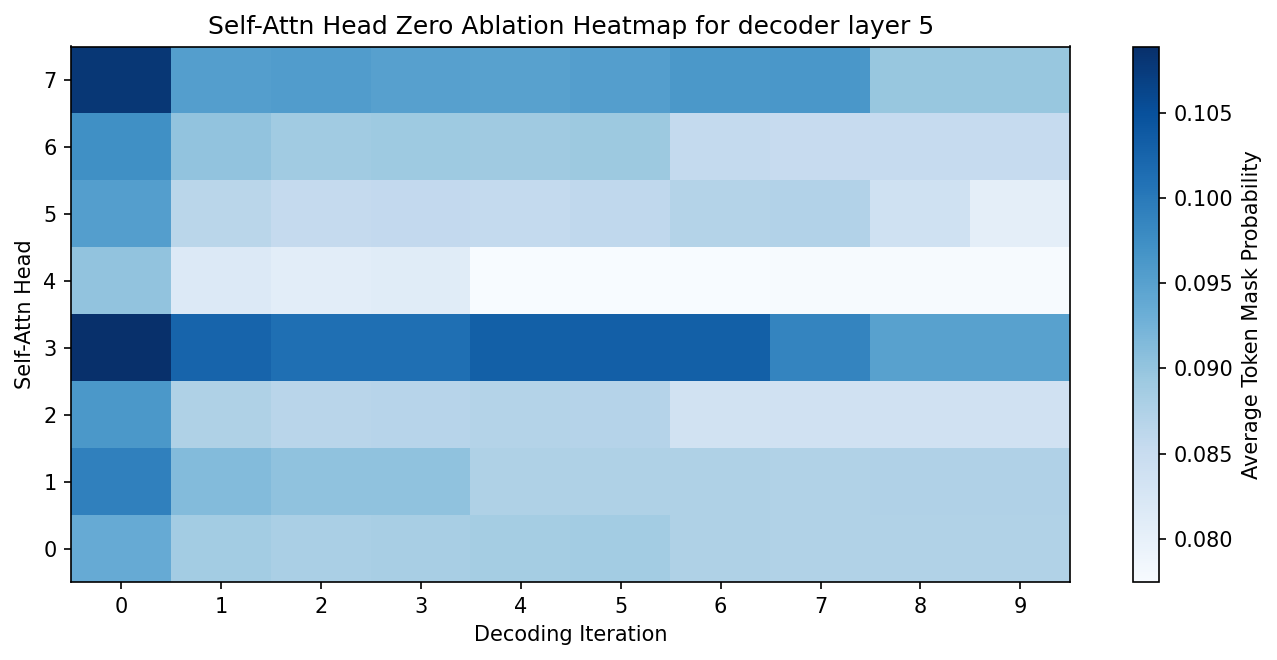

In [299]:
plot_self_attn_zero_out_layer_sweep_heatmaps(
    self_attn_zero_out_layer_sweep_result,
    cmap="Blues",
)
plot_self_attn_zero_out_average_heatmap(self_attn_zero_out_layer_sweep_result, cmap="Blues")

## Cross-attn zero-out


In [300]:
cross_attn_zero_out_layer_indices = list(range(len(context["model"].decoder.layers)))
cross_attn_zero_out_average_layer_indices = cross_attn_zero_out_layer_indices[:5]

print("cross-attn zero-out layer indices:", cross_attn_zero_out_layer_indices)
print("cross-attn average layer indices (first 5 layers):", cross_attn_zero_out_average_layer_indices)
print("target sentence for cross-attn zero-out:", target_sentence)

cross-attn head zero layer index: 5
target sentence for head zero ablation: The bank is open beside the park .


In [301]:
cross_attn_zero_out_layer_sweep_result = decoder_cross_attn_zero_out_layer_sweep(
    target_sentence=target_sentence,
    context=context,
    layer_indices=cross_attn_zero_out_layer_indices,
    average_layer_indices=cross_attn_zero_out_average_layer_indices,
    decoding_iterations=iter_nums,
)

In [302]:
print("cross-attn zero-out results by layer:")
for layer_result in cross_attn_zero_out_layer_sweep_result["layer_results"]:
    print(f"layer {layer_result['layer_index']}:")
    for head_result in layer_result["head_results"]:
        print(
            f"  head {head_result['head_index']}: overall avg mask prob = {head_result['overall_average_mask_prob']}"
        )
        print("    avg mask probs by iteration:", head_result["average_token_mask_probs_by_iteration"])
        print("    decoded text:", head_result["decoded_text"])

cross-attn head zero ablation results:
head 0: overall avg mask prob = 0.110192
  avg mask probs by iteration: [0.12562, 0.108177, 0.107121, 0.107112, 0.107568, 0.111666, 0.112214, 0.107811, 0.107318, 0.107318]
  decoded text: Die Bank ist neben dem Park geöffnet .
head 1: overall avg mask prob = 0.085018
  avg mask probs by iteration: [0.093109, 0.085266, 0.084333, 0.084577, 0.084476, 0.084788, 0.085823, 0.085945, 0.082565, 0.0793]
  decoded text: Die Bank ist neben dem Park geöffnet .
head 2: overall avg mask prob = 0.088096
  avg mask probs by iteration: [0.100231, 0.088767, 0.088726, 0.085878, 0.08635, 0.086357, 0.08629, 0.086115, 0.086122, 0.086122]
  decoded text: Die Bank ist neben dem Park geöffnet .
head 3: overall avg mask prob = 0.114313
  avg mask probs by iteration: [0.12566, 0.114731, 0.115119, 0.113984, 0.113892, 0.114431, 0.115779, 0.116016, 0.106761, 0.106761]
  decoded text: Die Bank ist neben dem Park geöffnet .
head 4: overall avg mask prob = 0.087195
  avg mask pro

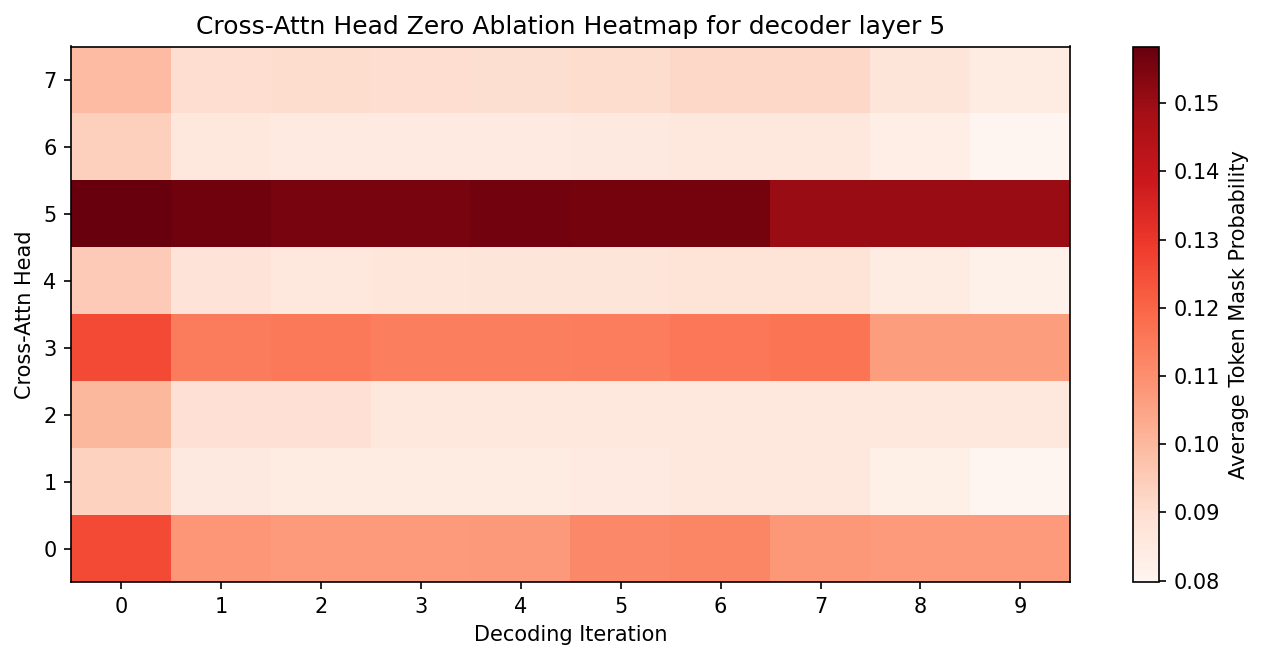

In [303]:
plot_cross_attn_zero_out_layer_sweep_heatmaps(
    cross_attn_zero_out_layer_sweep_result,
    cmap="Reds",
)
plot_cross_attn_zero_out_average_heatmap(cross_attn_zero_out_layer_sweep_result, cmap="Reds")